# Week 13 consolidated Bayesian optimisation notebook

This notebook presents Functions 1–8 in one systematic analytical record. Every function follows the same eleven-stage sequence below. UCB results are unevaluated proposals and are never appended as returned observations.

**Evidence used:** starter observations plus immutable-ledger returns through Week 12.

## Table of contents

1. Create week's_dataset by appending the previous output results
2. Extract the function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

# Function 1

Function 1 uses the verified evidence available before Week 13.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 1, 2, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [2]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
12,week_03,0.614168,0.334143,-1.075594e-32
13,week_04,0.872626,0.321598,-2.466641e-107
14,week_05,0.897714,0.081699,7.651210e-239
15,week_06,0.222521,0.999673,6.131855e-211
16,week_07,0.350420,0.999543,-6.738616e-151
17,week_08,0.397837,0.919531,-1.772400e-96
18,week_09,0.421410,0.935804,-3.089424e-96
19,week_10,0.379403,0.071186,-4.592141e-89
20,week_11,0.353293,0.956697,8.159220e-130


## 2. Extract the function

In [3]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 1: 2 input dimensions, 22 verified observations


## 3. Check shapes and missing values

In [4]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(22, 2)"
1,output shape,"(22,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [5]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,22.0,0.541202,0.250529,0.082507,3.586048e-01,4.789195e-01,7.191223e-01,9.979150e-01
x2,22.0,0.615915,0.336517,0.071186,3.247343e-01,7.409984e-01,9.096228e-01,9.996730e-01
output,22.0,-0.000164,0.000769,-0.003606,-2.760168e-96,-3.369308e-151,1.001025e-79,7.710875e-16


## 5. Plot the output trend

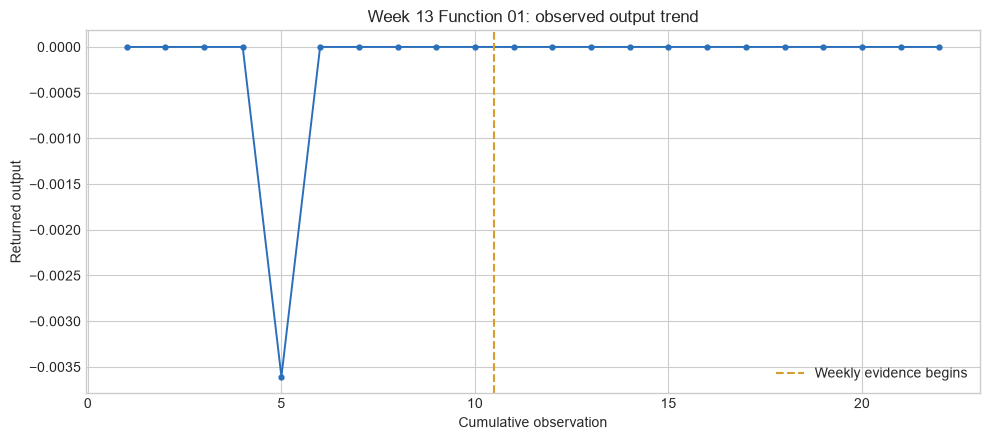

In [6]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

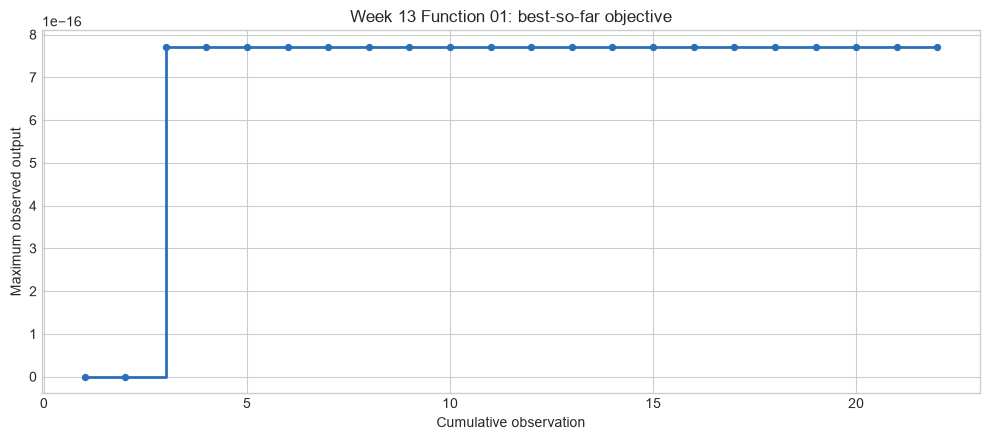

In [7]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [8]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,3,starter,0.731024,0.733,7.710875e-16


## 8. Plot the correlation heatmap

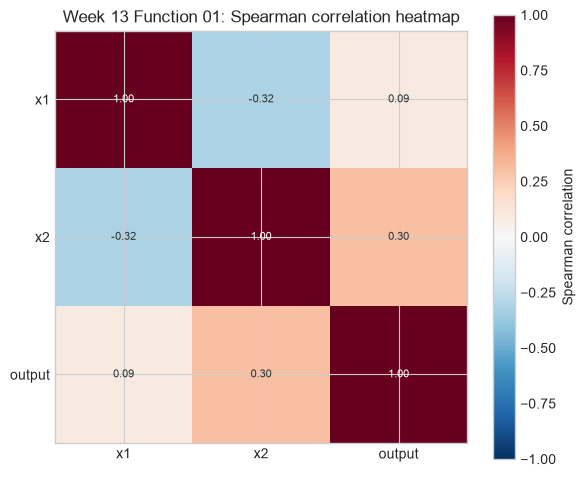

In [9]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

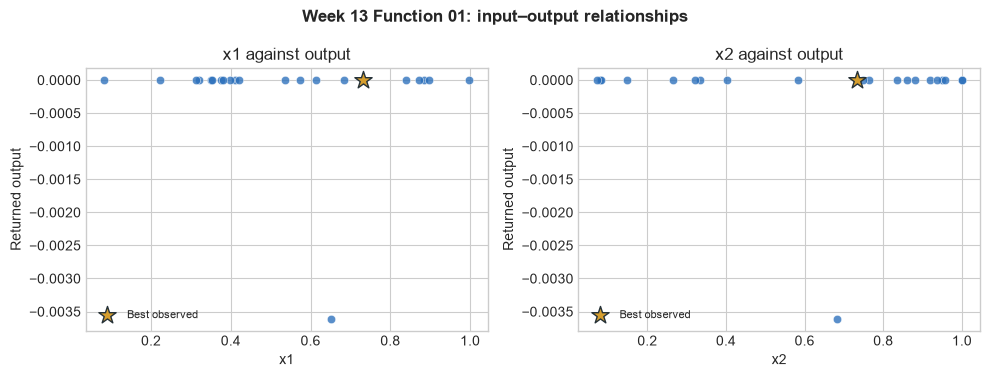

In [10]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [11]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.24**2 * Matern(length_scale=[10, 0.0469], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [12]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_1:0.994829-0.509095


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,13,1,2.0,0.994829,0.509095,-0.000009,0.000891,0.001773,proposed_not_evaluated


# Function 2

Function 2 uses the verified evidence available before Week 13.

In [13]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 2, 2, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [14]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,output
observation,,,,
12,week_03,0.000006,0.334143,0.048684
13,week_04,0.197553,0.808683,0.038775
14,week_05,0.555332,0.360931,0.220781
15,week_06,0.473151,0.950706,0.160532
16,week_07,0.009675,0.999881,0.048714
17,week_08,0.314242,0.973527,0.072764
18,week_09,0.995366,0.102732,0.049406
19,week_10,0.329121,0.997950,0.026788
20,week_11,0.384537,0.996119,0.065300


## 2. Extract the function

In [15]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 2: 2 input dimensions, 22 verified observations


## 3. Check shapes and missing values

In [16]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(22, 2)"
1,output shape,"(22,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [17]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,22.0,0.485905,0.285096,0.000006,0.331503,0.446407,0.685829,0.995366
x2,22.0,0.632119,0.339211,0.028698,0.337859,0.741547,0.946212,0.999881
output,22.0,0.165305,0.207336,-0.065624,0.029779,0.057353,0.238660,0.611205


## 5. Plot the output trend

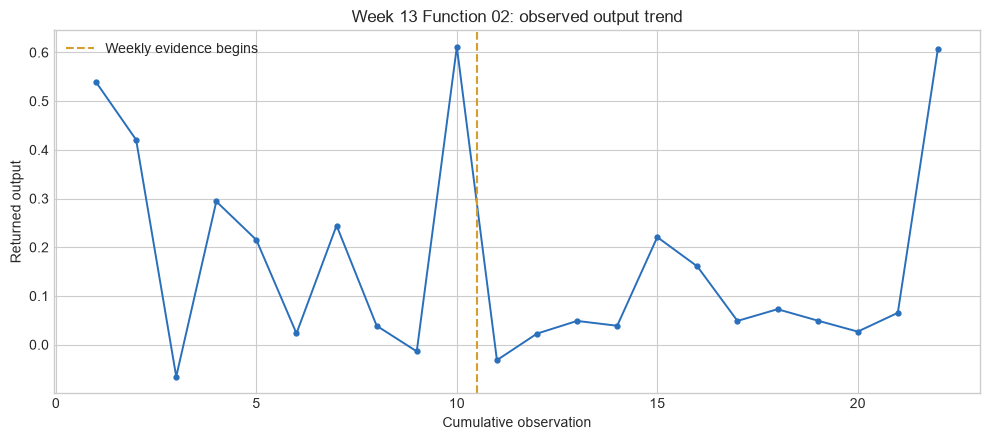

In [18]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

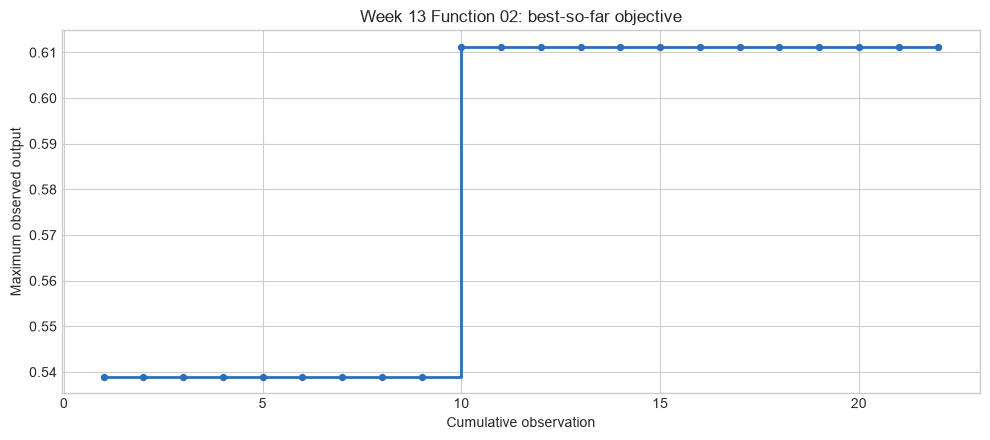

In [19]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [20]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,output
0,10,starter,0.702637,0.926564,0.611205


## 8. Plot the correlation heatmap

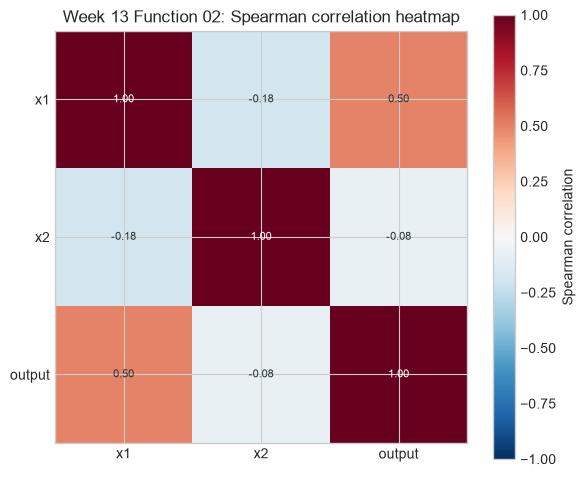

In [21]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

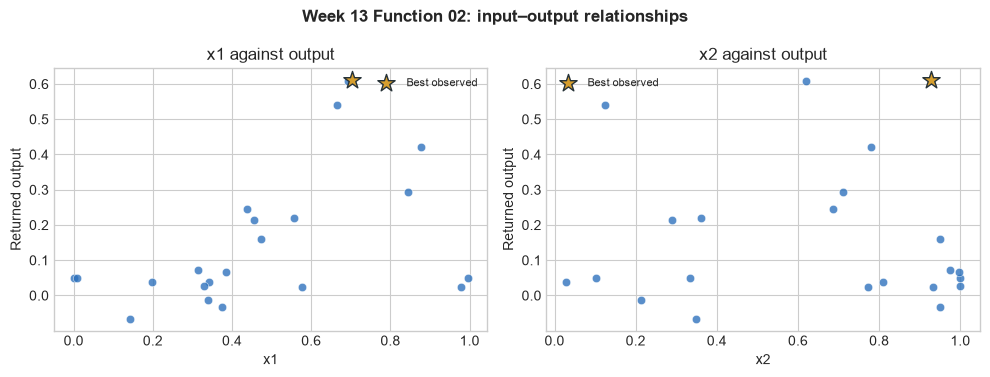

In [22]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [23]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.913**2 * Matern(length_scale=[0.0493, 10], nu=2.5) + WhiteKernel(noise_level=0.0189)
Training R²: 0.9960


## 11. Apply UCB to generate the next query point

In [24]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_2:0.728506-0.053397


,week,function,kappa,x1,x2,predicted_mean,predicted_std,ucb_score,status
0,13,2,2.0,0.728506,0.053397,0.493965,0.104549,0.703063,proposed_not_evaluated


# Function 3

Function 3 uses the verified evidence available before Week 13.

In [25]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 3, 3, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [26]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,output
observation,,,,,
17,week_03,0.670026,0.057881,0.658241,-0.183239
18,week_04,0.650132,0.218327,0.110542,-0.082513
19,week_05,0.522711,0.090769,0.451242,-0.057397
20,week_06,0.418776,0.420613,0.695421,-0.117005
21,week_07,0.427731,0.669810,0.343678,-0.047183
22,week_08,0.457347,0.664022,0.295993,-0.077413
23,week_09,0.449035,0.664262,0.290384,-0.081893
24,week_10,0.447317,0.658930,0.324854,-0.046339
25,week_11,0.450034,0.667941,0.342989,-0.038446


## 2. Extract the function

In [27]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 3: 3 input dimensions, 27 verified observations


## 3. Check shapes and missing values

In [28]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(27, 3)"
1,output shape,"(27,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [29]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,27.0,0.461790,0.223752,0.046809,0.293819,0.450034,0.647817,0.965995
x2,27.0,0.528028,0.251913,0.057881,0.320871,0.644074,0.670898,0.998464
x3,27.0,0.410343,0.246675,0.066089,0.259050,0.340176,0.512518,0.990882
output,27.0,-0.092309,0.071996,-0.398926,-0.111768,-0.082513,-0.047065,-0.022629


## 5. Plot the output trend

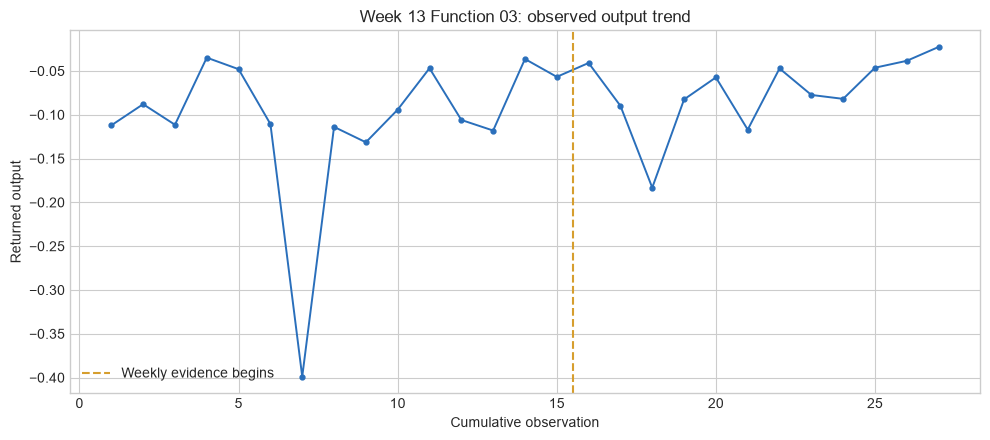

In [30]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

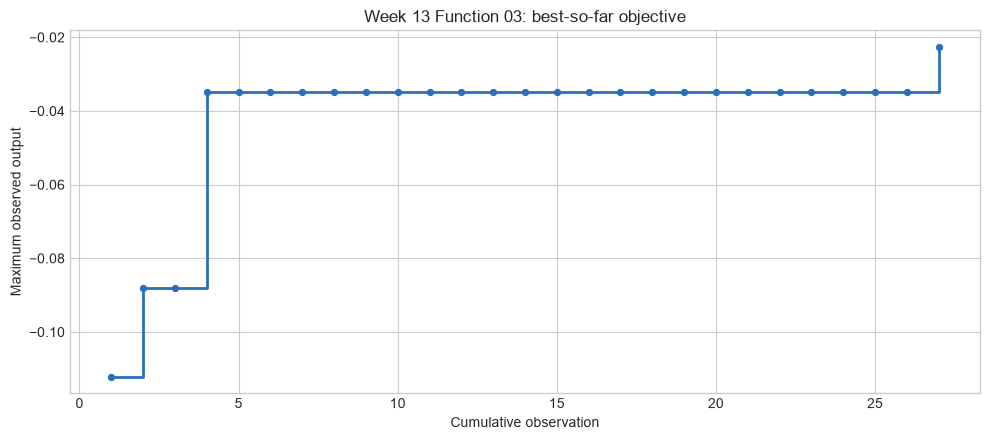

In [31]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [32]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,output
0,27,week_12,0.737864,0.713916,0.373523,-0.022629


## 8. Plot the correlation heatmap

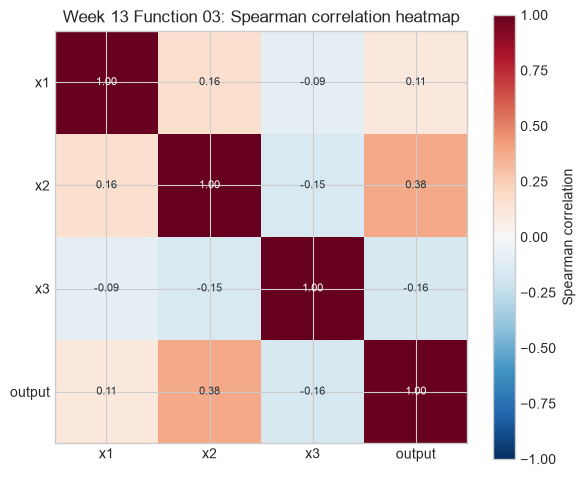

In [33]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

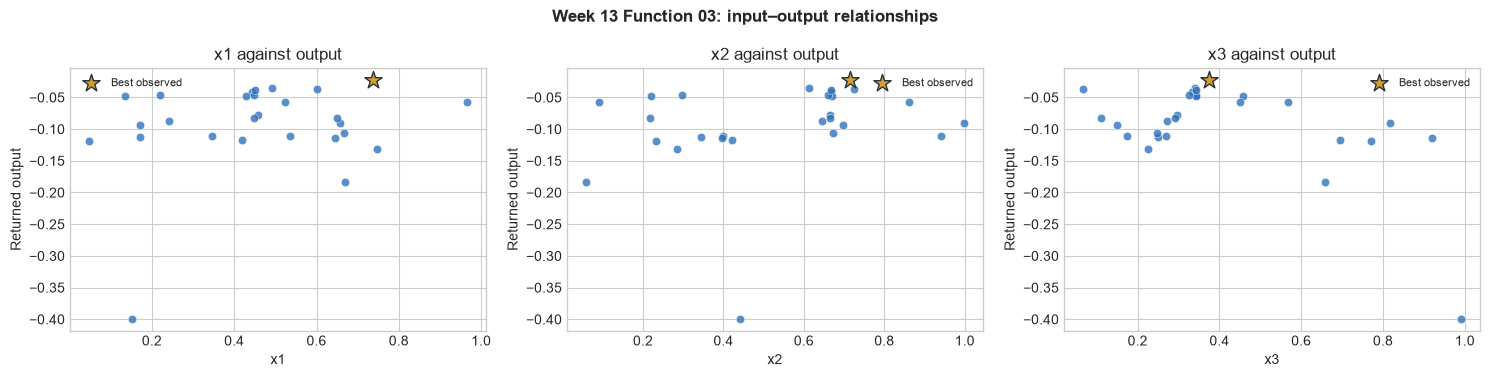

In [34]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [35]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.7**2 * Matern(length_scale=[10, 1.85, 0.106], nu=2.5) + WhiteKernel(noise_level=0.00461)
Training R²: 0.9990


## 11. Apply UCB to generate the next query point

In [36]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_3:0.773533-0.058619-0.000802


,week,function,kappa,x1,x2,x3,predicted_mean,predicted_std,ucb_score,status
0,13,3,2.0,0.773533,0.058619,0.000802,-0.04349,0.081096,0.118702,proposed_not_evaluated


# Function 4

Function 4 uses the verified evidence available before Week 13.

In [37]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 4, 4, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [38]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
32,week_03,0.394519,0.361122,0.256803,0.461856,-1.981075
33,week_04,0.715715,0.504442,0.275065,0.552962,-9.312812
34,week_05,0.713766,0.198601,0.014095,0.068347,-17.926307
35,week_06,0.753422,0.441826,0.942545,0.489846,-20.879363
36,week_07,0.096005,0.028299,0.033322,0.077327,-20.195854
37,week_08,0.046009,0.778273,0.979511,0.088488,-28.736323
38,week_09,0.889493,0.002958,0.445975,0.774547,-23.422803
39,week_10,0.587928,0.514452,0.045793,0.032616,-15.125731
40,week_11,0.807660,0.348421,0.277162,0.044827,-14.992666


## 2. Extract the function

In [39]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 4: 4 input dimensions, 42 verified observations


## 3. Check shapes and missing values

In [40]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(42, 4)"
1,output shape,"(42,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [41]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,42.0,0.529118,0.295533,0.006280,0.258744,0.582847,0.751742,0.985622
x2,42.0,0.442880,0.287725,0.002958,0.174215,0.477235,0.666413,0.919592
x3,42.0,0.448105,0.289017,0.014095,0.218485,0.425479,0.708686,0.979511
x4,42.0,0.435141,0.301933,0.032616,0.116675,0.451590,0.718294,0.999483
output,42.0,-16.900558,7.907167,-32.625660,-21.801057,-16.040082,-12.696705,0.369975


## 5. Plot the output trend

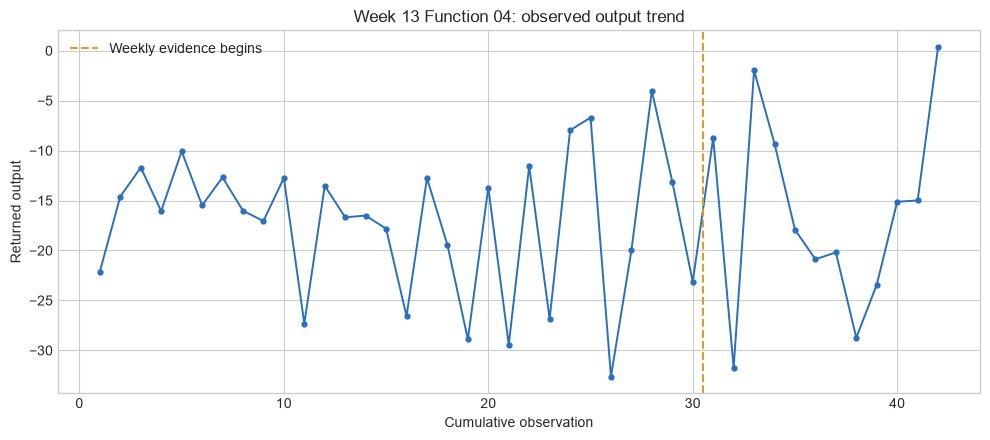

In [42]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

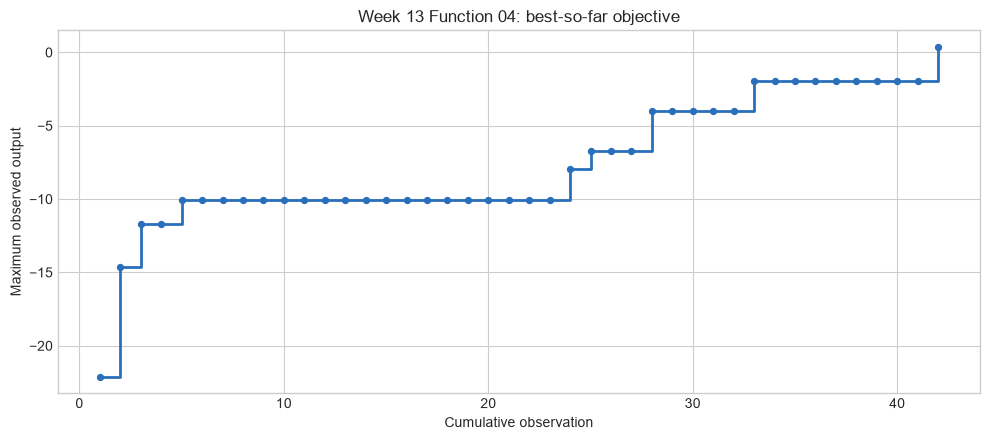

In [43]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [44]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,42,week_12,0.370439,0.382409,0.425133,0.390888,0.369975


## 8. Plot the correlation heatmap

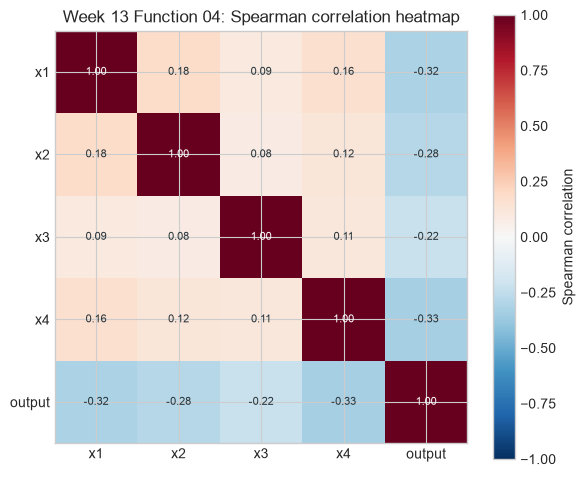

In [45]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

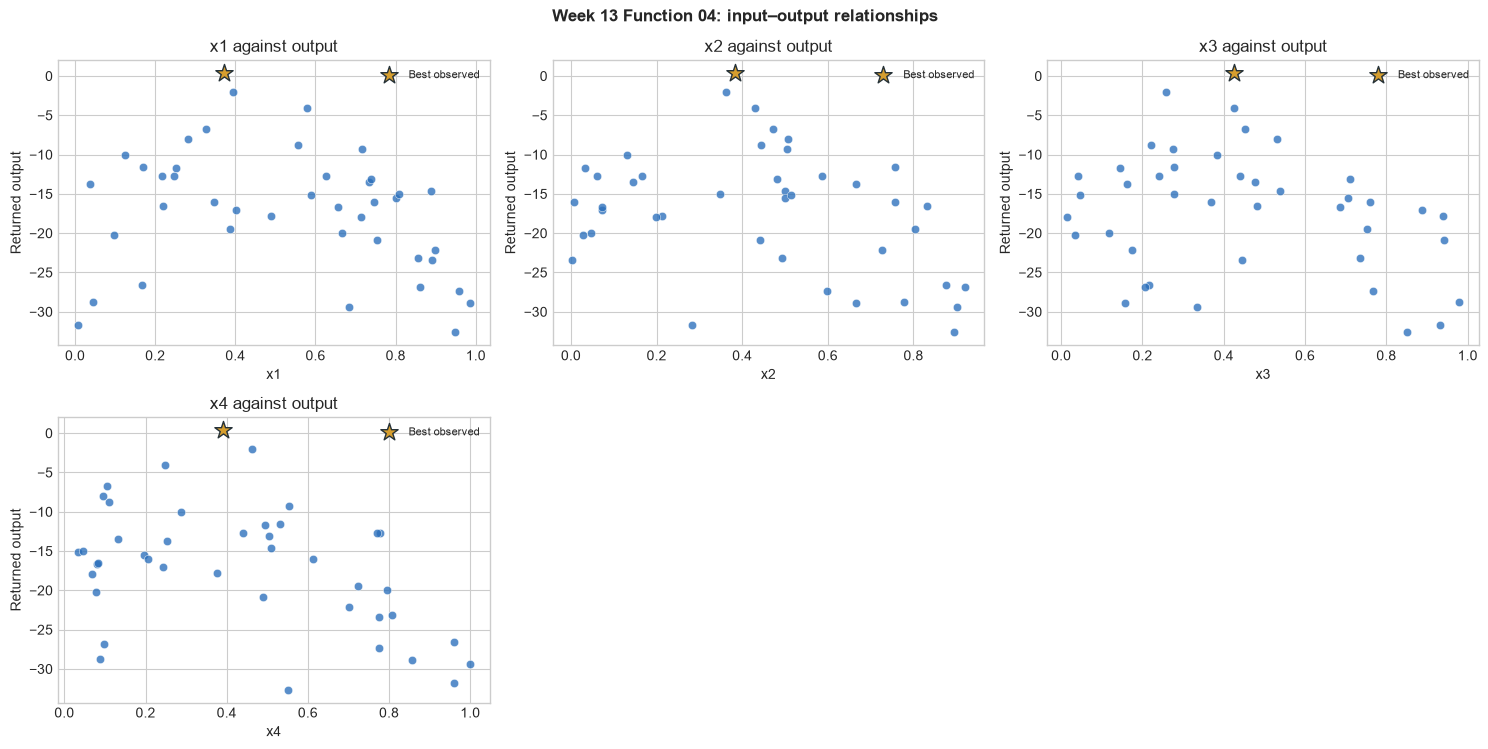

In [46]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [47]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.26**2 * Matern(length_scale=[1.59, 1.56, 1.52, 1.58], nu=2.5) + WhiteKernel(noise_level=1e-06)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [48]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_4:0.354925-0.341023-0.492017-0.440266


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,13,4,2.0,0.354925,0.341023,0.492017,0.440266,-0.186508,0.327316,0.468124,proposed_not_evaluated


# Function 5

Function 5 uses the verified evidence available before Week 13.

In [49]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 5, 4, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [50]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,output
observation,,,,,,
22,week_03,0.255842,0.841692,0.888985,0.860266,1035.664748
23,week_04,0.000000,0.000000,0.000000,0.000000,163.122500
24,week_05,0.754614,0.504566,0.432986,0.307039,0.940116
25,week_06,0.654981,0.602894,0.898891,0.589622,281.911573
26,week_07,0.000000,0.000000,0.000000,0.000000,163.122500
27,week_08,0.081230,0.992582,0.156202,0.988421,1465.512192
28,week_09,0.319924,0.675406,0.431628,1.000000,430.803125
29,week_10,0.005552,0.918769,0.692571,0.988052,1424.636601
30,week_11,0.016444,0.027486,0.656999,0.955172,210.038313


## 2. Extract the function

In [51]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 5: 4 input dimensions, 32 verified observations


## 3. Check shapes and missing values

In [52]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(32, 4)"
1,output shape,"(32,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [53]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,32.0,0.371112,0.260984,0.00000,0.147060,0.336140,0.601725,0.836478
x2,32.0,0.536851,0.317433,0.00000,0.286061,0.616459,0.823891,0.992582
x3,32.0,0.514509,0.294258,0.00000,0.308915,0.543505,0.739073,0.978678
x4,32.0,0.572343,0.348555,0.00000,0.277909,0.578599,0.878515,1.000000
output,32.0,433.509650,720.642427,0.11294,41.102866,136.347188,431.005533,3546.631969


## 5. Plot the output trend

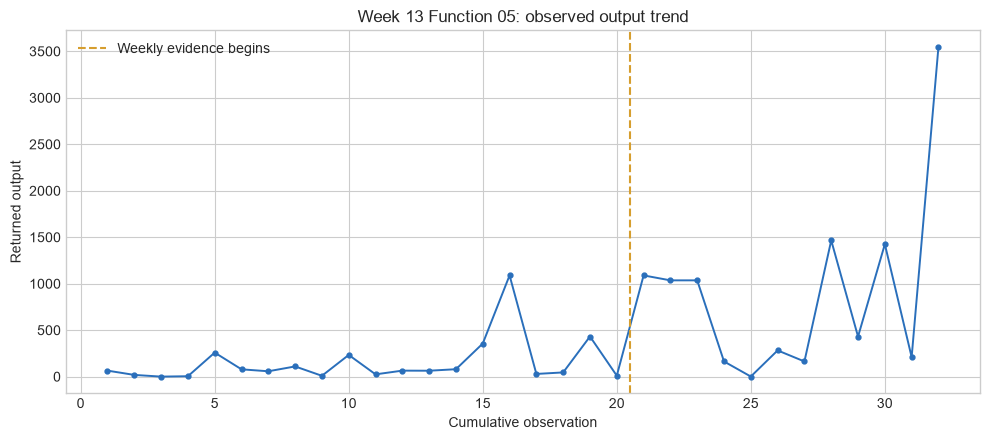

In [54]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

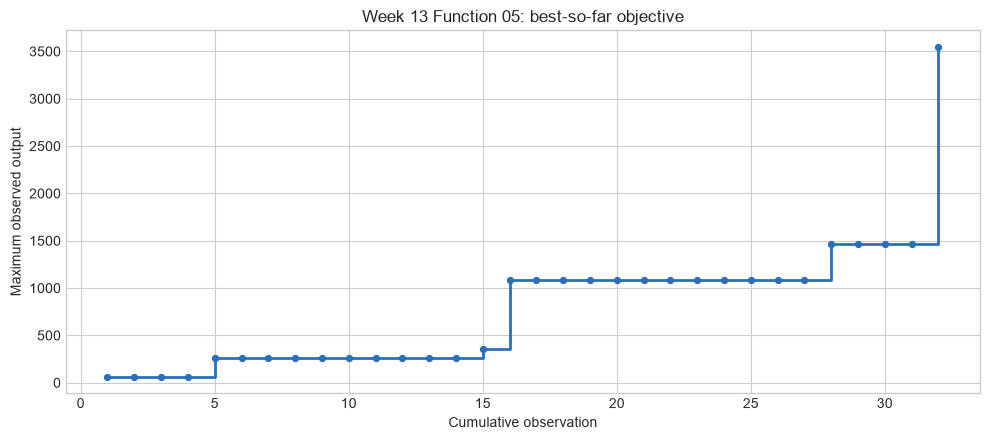

In [55]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [56]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,output
0,32,week_12,0.09922,0.956523,0.978678,0.993262,3546.631969


## 8. Plot the correlation heatmap

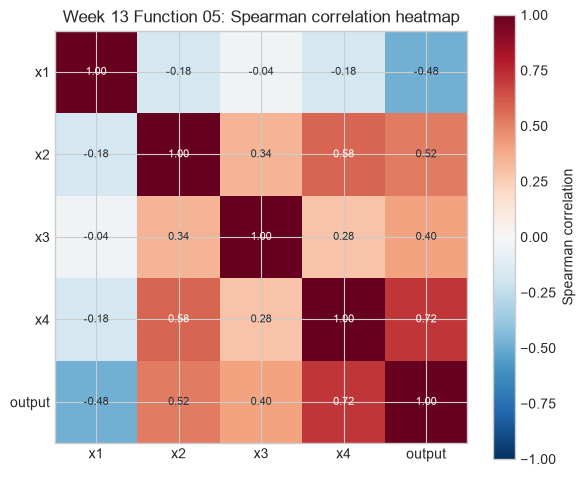

In [57]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

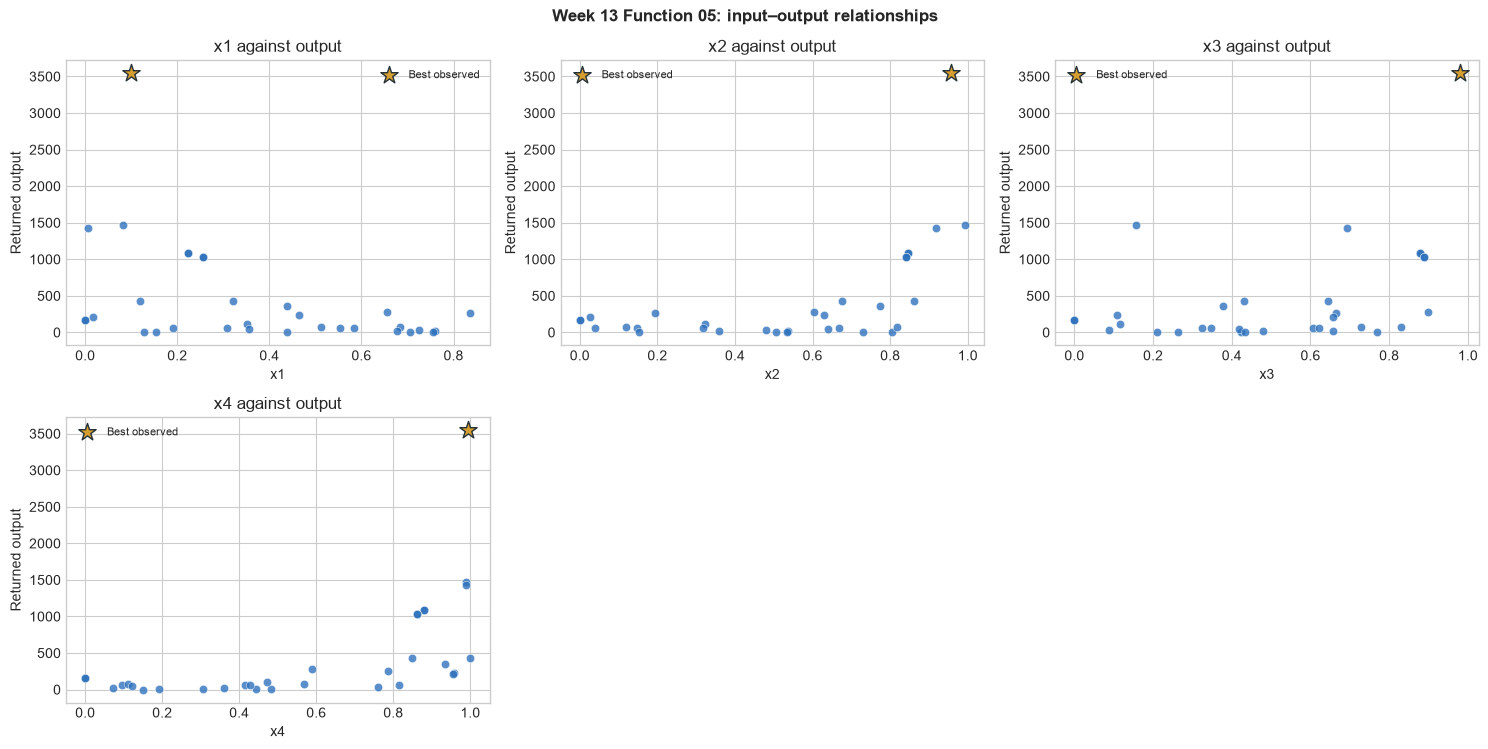

In [58]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [59]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 1.08**2 * Matern(length_scale=[10, 0.032, 10, 10], nu=2.5) + WhiteKernel(noise_level=2.3e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [60]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_5:0.956433-0.951518-0.048545-0.195224


,week,function,kappa,x1,x2,x3,x4,predicted_mean,predicted_std,ucb_score,status
0,13,5,2.0,0.956433,0.951518,0.048545,0.195224,3430.844459,185.774997,3802.394453,proposed_not_evaluated


# Function 6

Function 6 uses the verified evidence available before Week 13.

In [61]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 6, 5, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [62]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,output
observation,,,,,,,
22,week_03,0.495070,0.097152,0.672921,0.000007,0.351268,-1.339542
23,week_04,0.973181,0.022807,0.714484,0.145453,0.974790,-2.437508
24,week_05,0.824244,0.022732,0.960907,0.041715,0.897560,-2.529369
25,week_06,0.781770,0.192076,0.805757,0.695733,0.565940,-1.312540
26,week_07,0.683830,0.035248,0.777884,0.740721,0.629310,-1.287089
27,week_08,0.994993,0.316819,0.508801,0.557706,0.579403,-1.479452
28,week_09,0.711755,0.175670,0.738396,0.689597,0.562717,-1.171713
29,week_10,0.853051,0.152023,0.700695,0.554516,0.611033,-1.449089
30,week_11,0.678590,0.144728,0.730278,0.715653,0.604728,-1.154424


## 2. Extract the function

In [63]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 6: 5 input dimensions, 32 verified observations


## 3. Check shapes and missing values

In [64]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(32, 5)"
1,output shape,"(32,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [65]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,32.0,0.614241,0.273533,0.021735,0.437922,0.697793,0.783399,0.994993
x2,32.0,0.414303,0.305452,0.022732,0.154693,0.312800,0.723740,0.931871
x3,32.0,0.548394,0.286923,0.016523,0.394364,0.657517,0.734013,0.978806
x4,32.0,0.545109,0.294170,0.000007,0.329066,0.663673,0.718308,0.972905
x5,32.0,0.474241,0.283038,0.004911,0.264230,0.563365,0.618549,0.974790
output,32.0,-1.457394,0.497826,-2.571170,-1.696397,-1.326041,-1.167391,-0.537822


## 5. Plot the output trend

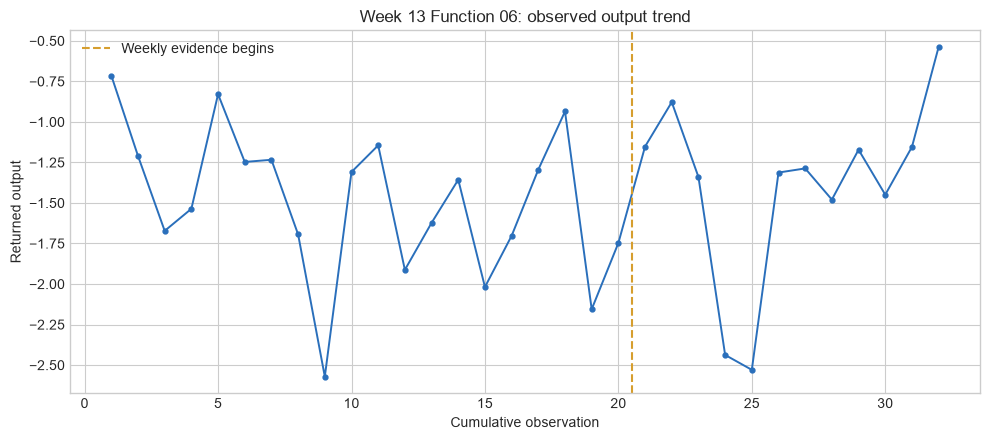

In [66]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

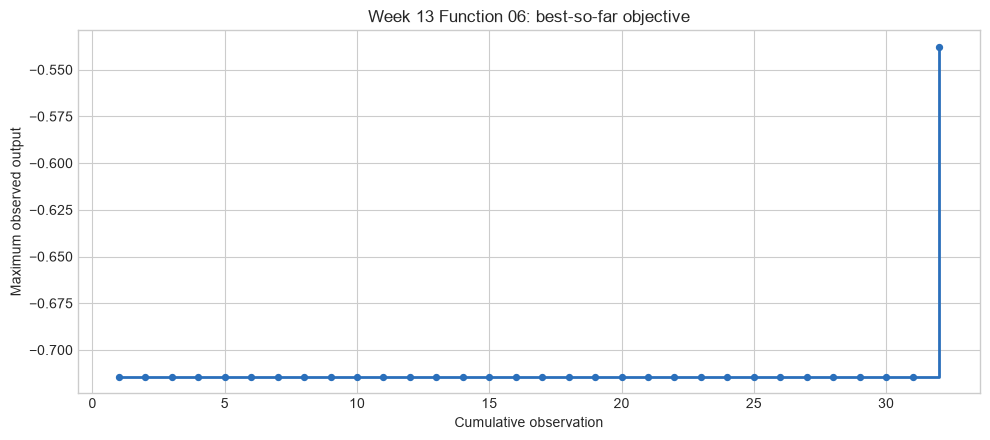

In [67]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [68]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,output
0,32,week_12,0.542094,0.205654,0.578843,0.946832,0.036709,-0.537822


## 8. Plot the correlation heatmap

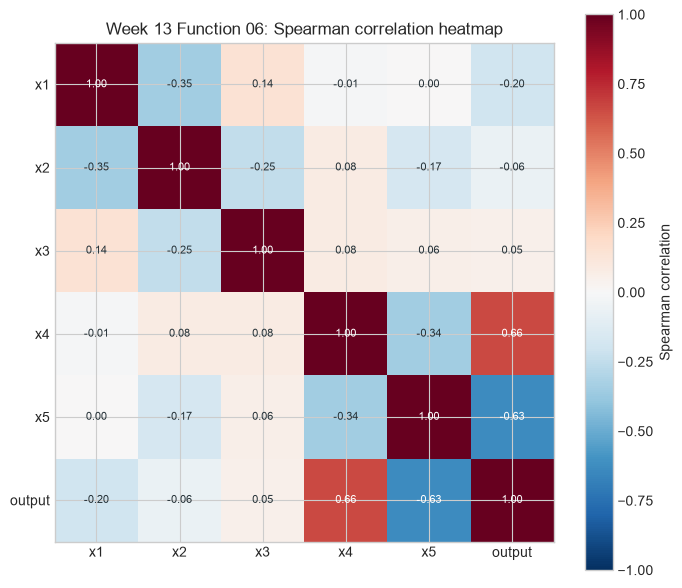

In [69]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

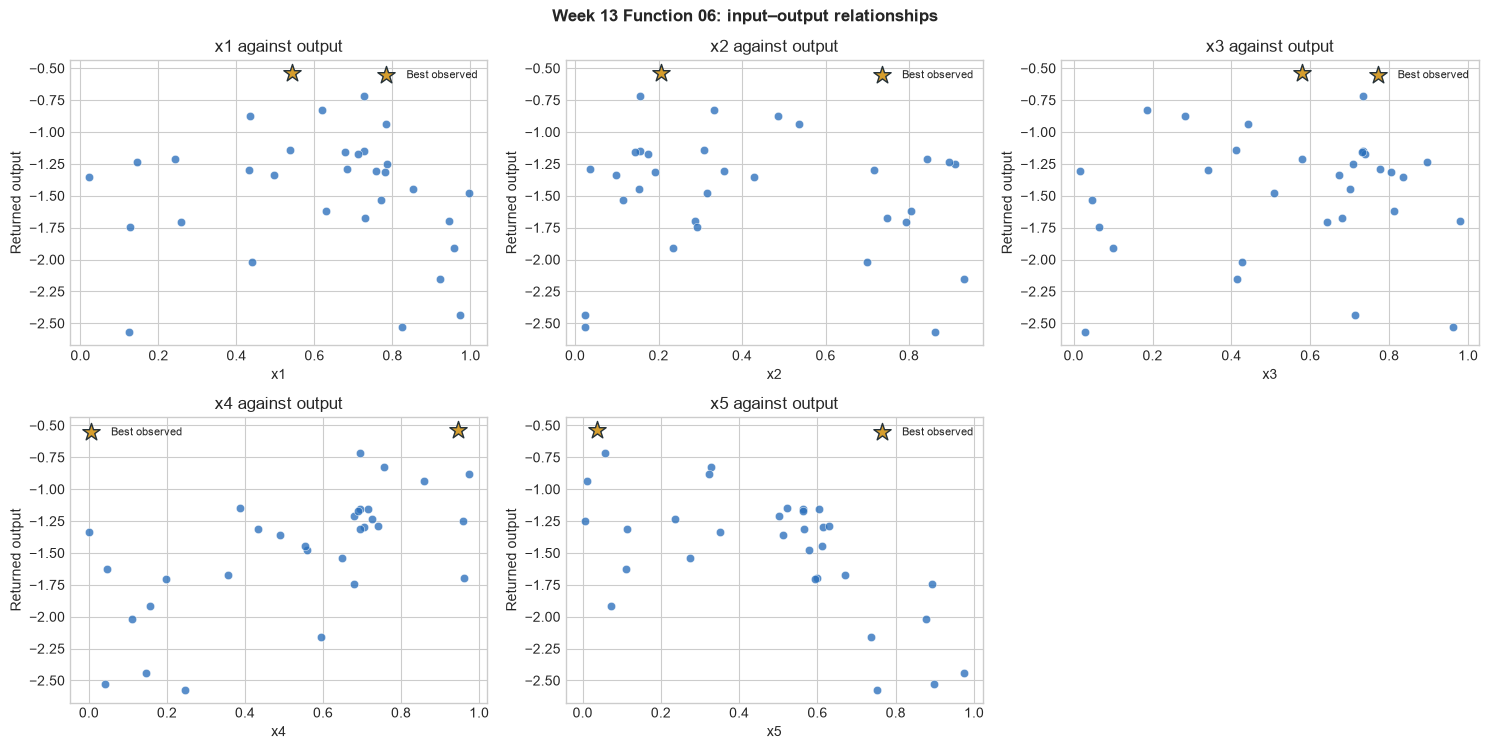

In [70]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [71]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 2.09**2 * Matern(length_scale=[1.18, 0.839, 1.13, 1.88, 2.03], nu=2.5) + WhiteKernel(noise_level=0.00113)
Training R²: 0.9999


## 11. Apply UCB to generate the next query point

In [72]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_6:0.221003-0.061139-0.717263-0.743459-0.039630


,week,function,kappa,x1,x2,x3,x4,x5,predicted_mean,predicted_std,ucb_score,status
0,13,6,2.0,0.221003,0.061139,0.717263,0.743459,0.03963,-0.702314,0.235122,-0.232071,proposed_not_evaluated


# Function 7

Function 7 uses the verified evidence available before Week 13.

In [73]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 7, 6, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [74]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,output
observation,,,,,,,,
32,week_03,0.143585,0.302559,0.571101,0.194533,0.395561,0.815792,2.149905
33,week_04,0.045103,0.016167,0.773003,0.156031,0.147073,0.616114,1.208733
34,week_05,0.025337,0.910075,0.727790,0.075231,0.386516,0.492629,0.190783
35,week_06,0.042873,0.466831,0.379623,0.207090,0.367754,0.515646,1.611967
36,week_07,0.121173,0.544849,0.282921,0.037758,0.374065,0.591179,0.899499
37,week_08,0.016174,0.558963,0.348588,0.050763,0.417748,0.644030,0.846180
38,week_09,0.018603,0.530937,0.376818,0.094048,0.443567,0.614974,1.009894
39,week_10,0.107447,0.625529,0.309529,0.130105,0.443660,0.667717,0.845637
40,week_11,0.280913,0.512275,0.321637,0.188234,0.420546,0.641027,1.478174


## 2. Extract the function

In [75]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 7: 6 input dimensions, 42 verified observations


## 3. Check shapes and missing values

In [76]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(42, 6)"
1,output shape,"(42,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [77]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,42.0,0.393438,0.320481,0.016174,0.107764,0.276768,0.713675,0.942451
x2,42.0,0.430292,0.253599,0.011813,0.267219,0.465863,0.556264,0.924694
x3,42.0,0.411324,0.282129,0.003635,0.246107,0.354342,0.662281,0.924571
x4,42.0,0.405842,0.315094,0.037758,0.158317,0.243684,0.710543,0.961017
x5,42.0,0.441741,0.271037,0.014944,0.260415,0.415690,0.671163,0.998655
x6,42.0,0.534386,0.247161,0.051100,0.360685,0.617598,0.707072,0.951014
output,42.0,0.487037,0.599270,0.002701,0.035703,0.237355,0.803013,2.266802


## 5. Plot the output trend

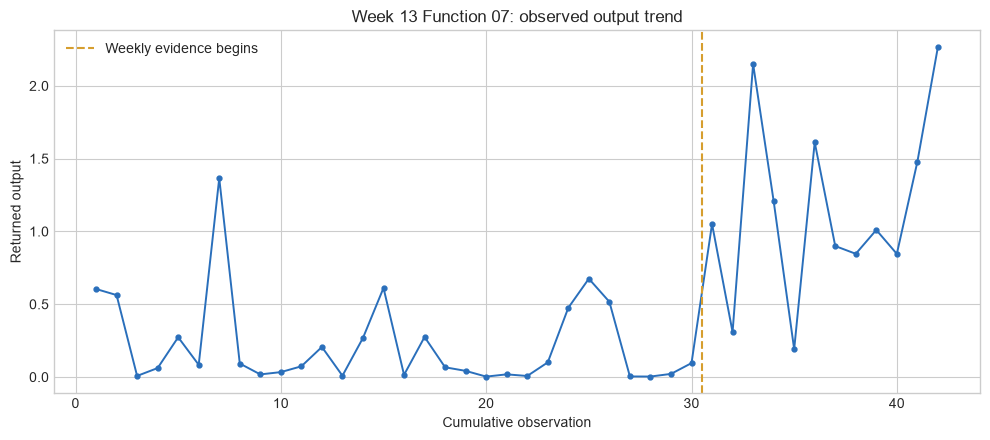

In [78]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

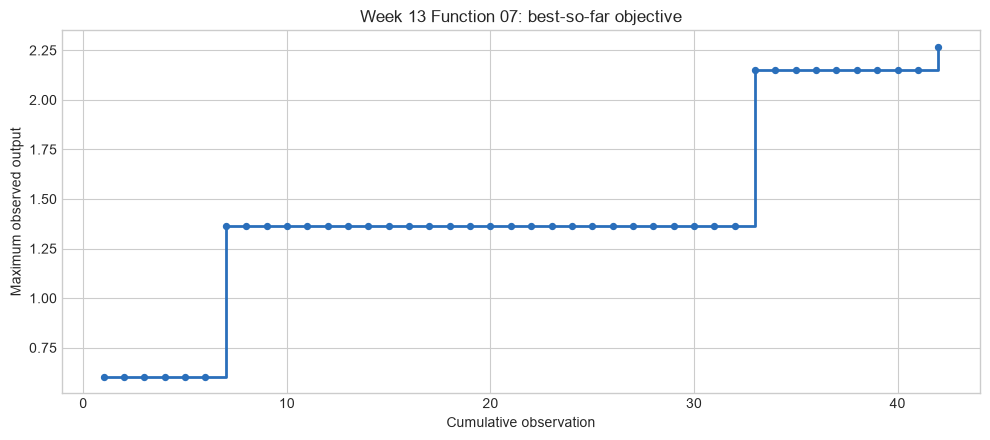

In [79]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [80]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,output
0,42,week_12,0.108717,0.301229,0.470084,0.22803,0.331784,0.836498,2.266802


## 8. Plot the correlation heatmap

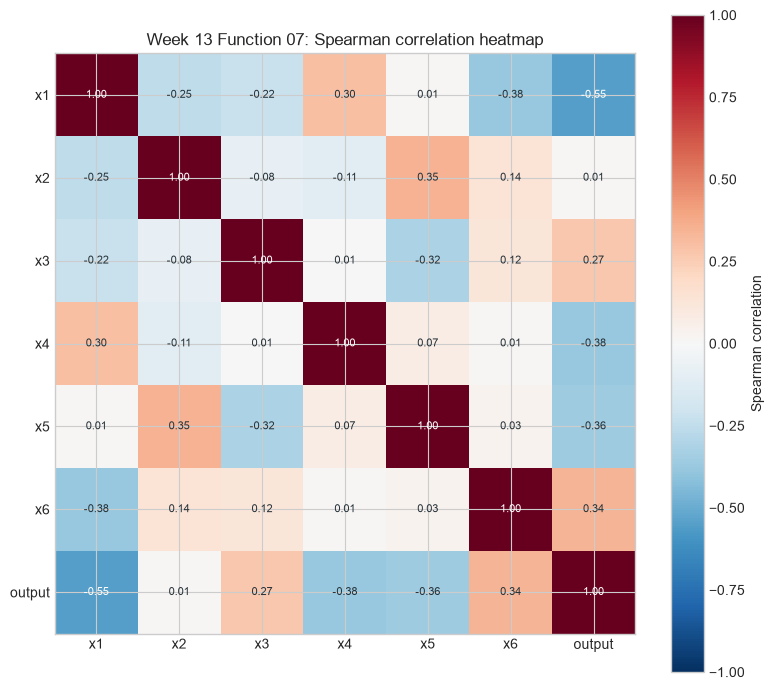

In [81]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

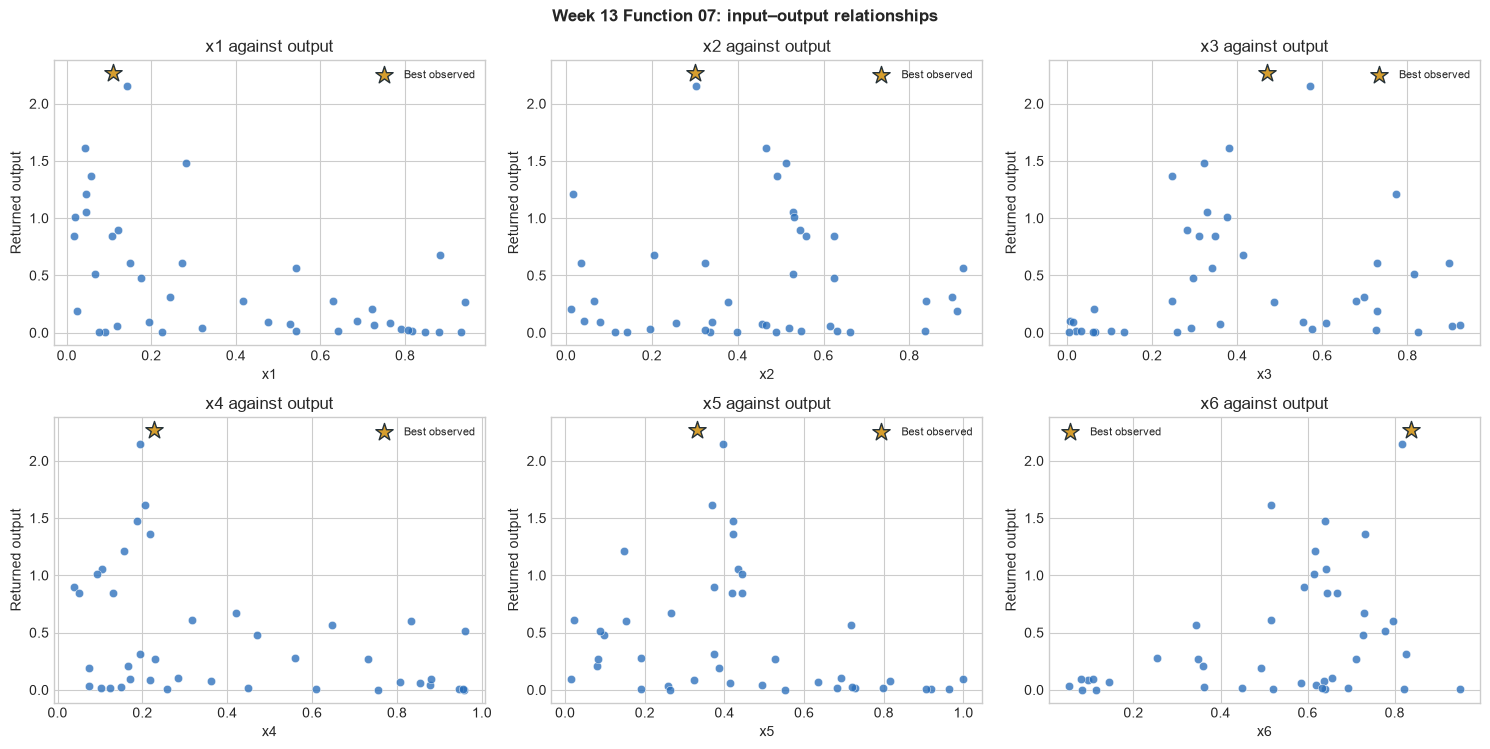

In [82]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [83]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 0.85**2 * Matern(length_scale=[0.647, 0.449, 1.86, 0.403, 0.291, 0.752], nu=2.5) + WhiteKernel(noise_level=1.3e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [84]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_7:0.157612-0.233690-0.589410-0.203231-0.330484-0.914103


,week,function,kappa,x1,x2,x3,x4,x5,x6,predicted_mean,predicted_std,ucb_score,status
0,13,7,2.0,0.157612,0.23369,0.58941,0.203231,0.330484,0.914103,2.28753,0.093172,2.473874,proposed_not_evaluated


# Function 8

Function 8 uses the verified evidence available before Week 13.

In [85]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

ROOT = Path.cwd().resolve()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    raise FileNotFoundError('Run this notebook with the repository root as the working directory.')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from Code.weekly_evidence import pairs_through_week
from Code.acquisition_function import upper_confidence_bound

WEEK, FUNCTION, DIMENSION, EVIDENCE_CUTOFF = 13, 8, 8, 12
KAPPA, CANDIDATE_COUNT = 2.0, 4096
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GOLD, INK = '#2A6FBB', '#D69E2E', '#263238'

## 1. Create week's_dataset by appending the previous output results

In [86]:
starter_dir = ROOT / f'Week_01/Function_{FUNCTION:02d}/03_Data'
starter_inputs = np.load(starter_dir / 'initial_inputs.npy').astype(float)
starter_outputs = np.load(starter_dir / 'initial_outputs.npy').astype(float).reshape(-1)
previous_pairs = pairs_through_week(EVIDENCE_CUTOFF, FUNCTION)
previous_inputs = np.asarray([query for query, _ in previous_pairs], dtype=float).reshape(-1, DIMENSION)
previous_outputs = np.asarray([output for _, output in previous_pairs], dtype=float)
cumulative_inputs = np.vstack([starter_inputs, previous_inputs])
cumulative_outputs = np.concatenate([starter_outputs, previous_outputs])
source = ['starter'] * len(starter_outputs) + [f'week_{index:02d}' for index in range(1, EVIDENCE_CUTOFF + 1)]
week_dataset = pd.DataFrame(cumulative_inputs, columns=[f'x{i}' for i in range(1, DIMENSION + 1)])
week_dataset.insert(0, 'source', source)
week_dataset['output'] = cumulative_outputs
week_dataset.index.name = 'observation'
week_dataset.tail(min(10, len(week_dataset)))

,source,x1,x2,x3,x4,x5,x6,x7,x8,output
observation,,,,,,,,,,
42,week_03,0.088894,0.525132,0.030986,0.992538,0.870819,0.217060,0.011239,0.447691,8.963604
43,week_04,0.356502,0.157574,0.172997,0.610561,0.106477,0.260297,0.411421,0.904740,9.254064
44,week_05,0.110992,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,9.138609
45,week_06,0.115956,0.821931,0.587418,0.022809,0.440260,0.965550,0.368459,0.301774,8.557034
46,week_07,0.006802,0.833571,0.147083,0.461921,0.263530,0.887722,0.724982,0.315234,8.563639
47,week_08,0.712683,0.197193,0.129585,0.337018,0.771044,0.106613,0.229839,0.008464,9.020091
48,week_09,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892
49,week_10,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.373668
50,week_11,0.234325,0.196964,0.387716,0.462450,0.845967,0.154645,0.549698,0.111557,9.276069


## 2. Extract the function

In [87]:
function_inputs = week_dataset.filter(regex=r'^x').to_numpy(dtype=float)
function_outputs = week_dataset['output'].to_numpy(dtype=float)
print(f'Function {FUNCTION}: {DIMENSION} input dimensions, {len(function_outputs)} verified observations')

Function 8: 8 input dimensions, 52 verified observations


## 3. Check shapes and missing values

In [88]:
quality = pd.DataFrame({
    'measure': ['input shape', 'output shape', 'missing inputs', 'missing outputs', 'non-finite inputs', 'non-finite outputs', 'out-of-bounds inputs'],
    'value': [str(function_inputs.shape), str(function_outputs.shape), int(np.isnan(function_inputs).sum()), int(np.isnan(function_outputs).sum()), int((~np.isfinite(function_inputs)).sum()), int((~np.isfinite(function_outputs)).sum()), int(((function_inputs < 0) | (function_inputs > 1)).sum())],
})
assert function_inputs.shape == (len(function_outputs), DIMENSION)
assert np.isfinite(function_inputs).all() and np.isfinite(function_outputs).all()
assert np.all((function_inputs >= 0) & (function_inputs <= 1))
quality

,measure,value
0,input shape,"(52, 8)"
1,output shape,"(52,)"
2,missing inputs,0
3,missing outputs,0
4,non-finite inputs,0
5,non-finite outputs,0
6,out-of-bounds inputs,0


## 4. Calculate summary statistics

In [89]:
summary_statistics = week_dataset.drop(columns='source').describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
x1,52.0,0.469978,0.311652,0.006802,0.172903,0.459583,0.772024,0.985945
x2,52.0,0.434229,0.306603,0.003419,0.166933,0.448247,0.665174,0.973980
x3,52.0,0.438457,0.295237,0.021301,0.207864,0.379438,0.701192,0.998885
x4,52.0,0.410940,0.285174,0.000000,0.130000,0.438626,0.644918,0.992538
x5,52.0,0.523812,0.296242,0.009649,0.259525,0.541671,0.771234,0.999322
x6,52.0,0.444215,0.283302,0.022113,0.230998,0.384489,0.706965,0.990244
x7,52.0,0.503901,0.284144,0.011239,0.241126,0.550523,0.750686,0.992914
x8,52.0,0.456882,0.290966,0.008464,0.178769,0.447265,0.685055,0.988755
output,52.0,8.156540,1.071920,5.592193,7.366171,8.281035,9.014829,9.939904


## 5. Plot the output trend

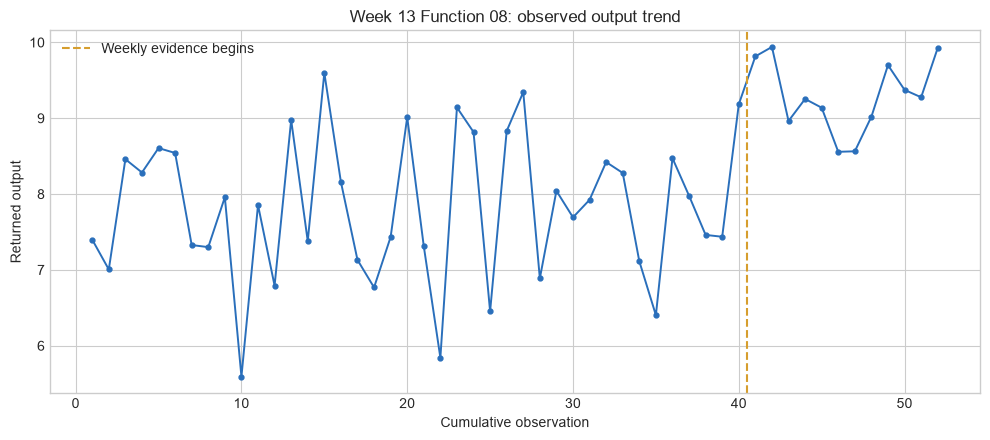

In [90]:
observation_number = np.arange(1, len(function_outputs) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observation_number, function_outputs, color=BLUE, marker='o', markersize=3.5, linewidth=1.4)
if EVIDENCE_CUTOFF: ax.axvline(len(starter_outputs) + .5, color=GOLD, linestyle='--', label='Weekly evidence begins')
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: observed output trend', xlabel='Cumulative observation', ylabel='Returned output')
if EVIDENCE_CUTOFF: ax.legend(frameon=False)
fig.tight_layout(); plt.show()

## 6. Plot the best-so-far trend

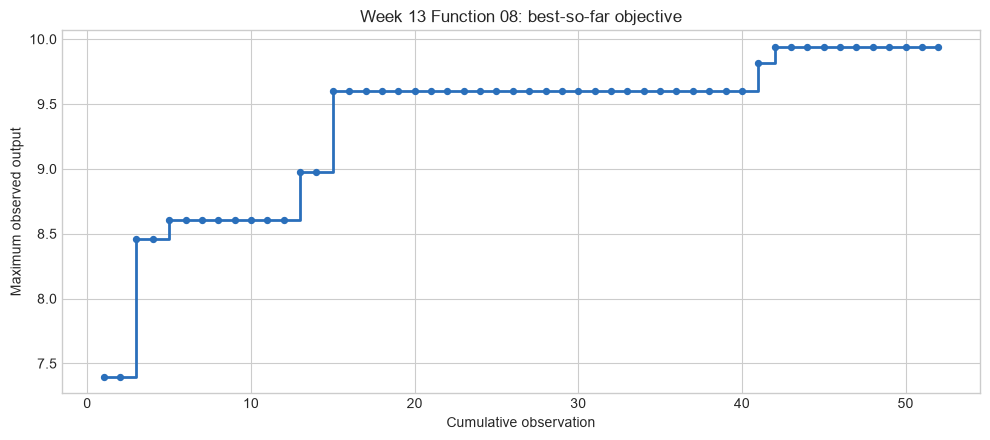

In [91]:
best_so_far = np.maximum.accumulate(function_outputs)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.step(observation_number, best_so_far, where='post', color=BLUE, linewidth=2)
ax.scatter(observation_number, best_so_far, color=BLUE, s=18)
ax.set(title=f'Week {WEEK:02d} Function {FUNCTION:02d}: best-so-far objective', xlabel='Cumulative observation', ylabel='Maximum observed output')
fig.tight_layout(); plt.show()

## 7. Identify the best query point

In [92]:
best_index = int(np.argmax(function_outputs))
best_query_point = pd.DataFrame([{
    'observation': best_index + 1, 'source': week_dataset.iloc[best_index]['source'],
    **{f'x{i + 1}': function_inputs[best_index, i] for i in range(DIMENSION)},
    'output': function_outputs[best_index],
}])
best_query_point

,observation,source,x1,x2,x3,x4,x5,x6,x7,x8,output
0,42,week_02,0.16316,0.184786,0.152644,0.083802,0.999322,0.544113,0.184124,0.123846,9.939904


## 8. Plot the correlation heatmap

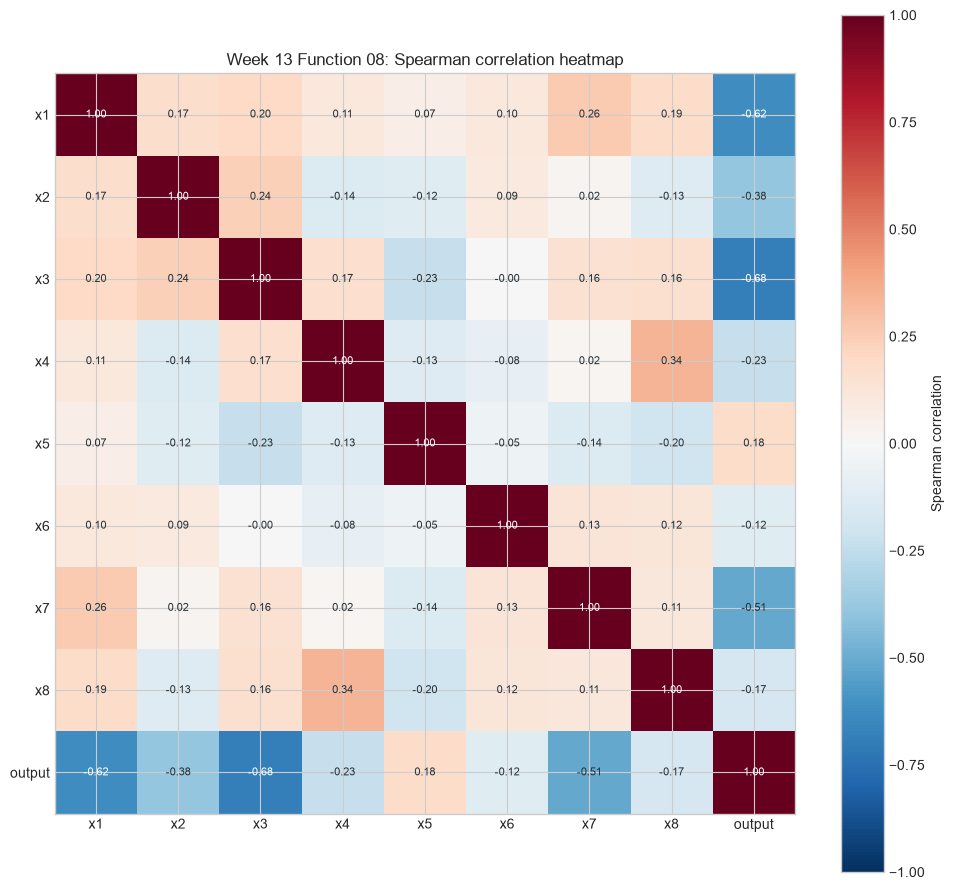

In [93]:
correlation = week_dataset.drop(columns='source').corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, DIMENSION + 2), max(5, DIMENSION + 1)))
image = ax.imshow(correlation, cmap='RdBu_r', vmin=-1, vmax=1)
labels = correlation.columns.tolist(); ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        ax.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(value) > .55 else INK)
ax.set_title(f'Week {WEEK:02d} Function {FUNCTION:02d}: Spearman correlation heatmap')
fig.colorbar(image, ax=ax, label='Spearman correlation'); fig.tight_layout(); plt.show()

## 9. Plot each input against the output

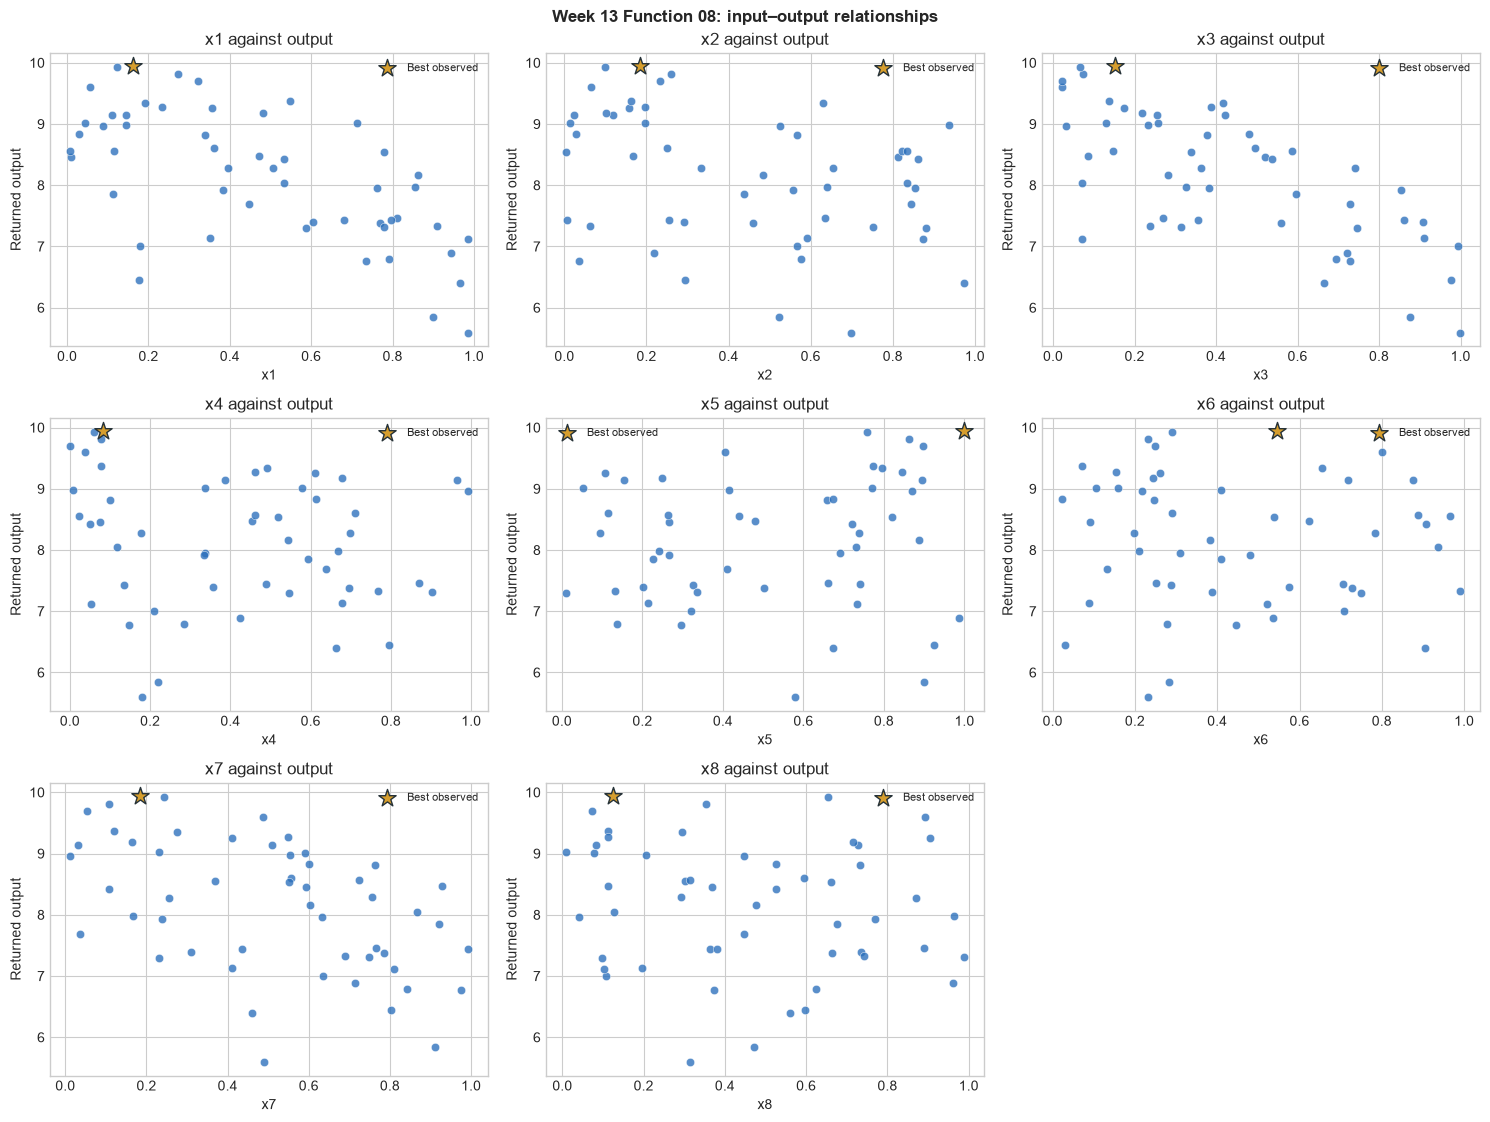

In [94]:
columns = min(3, DIMENSION); rows = int(np.ceil(DIMENSION / columns))
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 3.8 * rows), squeeze=False)
for index, ax in enumerate(axes.ravel()):
    if index >= DIMENSION: ax.axis('off'); continue
    ax.scatter(function_inputs[:, index], function_outputs, color=BLUE, alpha=.78, edgecolor='white', linewidth=.4)
    ax.scatter(function_inputs[best_index, index], function_outputs[best_index], marker='*', s=170, color=GOLD, edgecolor=INK, label='Best observed')
    ax.set(xlabel=f'x{index + 1}', ylabel='Returned output', title=f'x{index + 1} against output')
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Week {WEEK:02d} Function {FUNCTION:02d}: input–output relationships', fontweight='bold')
fig.tight_layout(); plt.show()

## 10. Fit a Gaussian Process surrogate

In [95]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.full(DIMENSION, .3), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
gaussian_process = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=1000 + WEEK * 10 + FUNCTION)
gaussian_process.fit(function_inputs, function_outputs)
training_r_squared = gaussian_process.score(function_inputs, function_outputs)
print('Fitted kernel:', gaussian_process.kernel_)
print(f'Training R²: {training_r_squared:.4f}')

Fitted kernel: 3.4**2 * Matern(length_scale=[3.34, 5.29, 2.77, 4.81, 10, 4.83, 3.47, 10], nu=2.5) + WhiteKernel(noise_level=1e-10)
Training R²: 1.0000


## 11. Apply UCB to generate the next query point

In [96]:
sobol_power = int(np.log2(CANDIDATE_COUNT))
candidate_points = qmc.Sobol(d=DIMENSION, scramble=True, seed=2000 + WEEK * 10 + FUNCTION).random_base2(sobol_power)
candidate_mean, candidate_std = gaussian_process.predict(candidate_points, return_std=True)
ucb_scores = upper_confidence_bound(candidate_mean, candidate_std, kappa=KAPPA)
rounded_candidates = np.round(candidate_points, 6)
observed_rounded = {tuple(row) for row in np.round(function_inputs, 6)}
duplicate_mask = np.array([tuple(row) in observed_rounded for row in rounded_candidates])
ucb_scores[duplicate_mask] = -np.inf
selected_index = int(np.argmax(ucb_scores))
next_query_point = rounded_candidates[selected_index]
assert np.isfinite(next_query_point).all() and np.all((next_query_point >= 0) & (next_query_point <= 1))
assert tuple(next_query_point) not in observed_rounded
ucb_proposal = pd.DataFrame([{
    'week': WEEK, 'function': FUNCTION, 'kappa': KAPPA,
    **{f'x{i + 1}': next_query_point[i] for i in range(DIMENSION)},
    'predicted_mean': candidate_mean[selected_index],
    'predicted_std': candidate_std[selected_index],
    'ucb_score': ucb_scores[selected_index],
    'status': 'proposed_not_evaluated',
}])
print(f"Function_{FUNCTION}:" + '-'.join(f'{value:.6f}' for value in next_query_point))
ucb_proposal

Function_8:0.055118-0.006949-0.398118-0.046222-0.936492-0.602993-0.242595-0.861642


,week,function,kappa,x1,x2,x3,x4,x5,x6,x7,x8,predicted_mean,predicted_std,ucb_score,status
0,13,8,2.0,0.055118,0.006949,0.398118,0.046222,0.936492,0.602993,0.242595,0.861642,9.843526,0.104383,10.052291,proposed_not_evaluated
